# Quant Methods in Finance - Project Notebook
## Chicago White Sox 2026 Statcast Pitch Analysis/Modeling
### Student - Sean Nicgorski


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import warnings
warnings.filterwarnings("ignore")
pd.options.display.max_rows = None

from pybaseball import statcast_pitcher, statcast # python package to pull from baseball savant directly

## Load Data from Statcast

In [3]:
data = statcast('2024-04-01', '2026-09-28')

# statcast indexes by day then combines data, to avoid downstream problems reset index here
data = data.reset_index(drop=True)

This is a large query, it may take a moment to complete
Skipping offseason dates
Skipping offseason dates


100%|██████████| 673/673 [12:15<00:00,  1.09s/it]


In [5]:
#preview
data.sample(10)

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
729502,FF,2026-03-21,95.9,-2.0,5.65,"Muñoz, Roddery",814514,682610,NaN,ball,...,<NA>,1.38,0.52,-0.52,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
778130,FC,2025-09-26,86.0,2.5,6.03,"Dodd, Dylan",669261,689266,NaN,foul,...,1,2.16,0.3,0.3,41.5,26.579021,-20.744188,38.2238,33.018066,38.926404
28644,ST,2026-09-20,83.9,2.11,5.57,"Bubic, Kris",687529,663460,field_out,hit_into_play,...,3,3.58,-1.26,-1.26,39.9,3.651593,3.91006,34.541984,36.233699,27.679753
1646000,SI,2024-09-02,95.4,-1.56,5.34,"Bello, Brayan",620443,678394,NaN,called_strike,...,6,2.05,1.52,1.52,33.0,<NA>,<NA>,<NA>,<NA>,<NA>
105796,FF,2026-09-01,94.6,1.91,5.68,"Macko, Adam",671732,671936,NaN,ball,...,1,1.05,0.59,0.59,39.4,<NA>,<NA>,<NA>,<NA>,<NA>
926029,SL,2025-08-20,87.0,1.36,5.95,"Dreyer, Jack",678662,676263,single,hit_into_play,...,1,2.65,-0.13,0.13,59.6,12.751621,-3.558292,43.685097,28.2161,30.29182
1881083,CU,2024-07-01,81.4,-2.06,6.48,"Molina, Anthony",606992,683627,NaN,called_strike,...,3,3.48,-0.2,-0.2,57.5,<NA>,<NA>,<NA>,<NA>,<NA>
196207,FF,2026-08-09,96.2,2.83,4.56,"Sommers, Drew",642715,805427,NaN,called_strike,...,1,1.67,0.99,-0.99,8.0,<NA>,<NA>,<NA>,<NA>,<NA>
218407,FF,2026-08-04,97.3,-1.8,5.64,"Silseth, Chase",687551,681217,NaN,ball,...,1,1.17,0.75,-0.75,32.5,<NA>,<NA>,<NA>,<NA>,<NA>
1929230,SI,2024-06-18,97.7,-1.6,6.05,"Mize, Casey",663586,663554,field_out,hit_into_play,...,1,1.25,1.2,1.2,44.4,3.002291,15.435259,30.465943,29.594302,28.099234


## Data Cleaning + Feature Engineering

### Chosen Columns + Descriptions

**Event info**
- `game_date` — date of the game
- `player_name` — pitcher's name
- `p_throws` — pitcher's throwing hand (R/L)
- `stand` — batter's stance (R/L)
- `inning` — inning number
- `outs_when_up` — number of outs when the pitch was thrown
- `balls` — ball count at the time of the pitch
- `strikes` — strike count at the time of the pitch
- `pitch_number` — pitch number within that plate appearance

**Pitching metrics**
- `pitch_type` — the type of pitch thrown

        (FF = 4-seam fastball, SL = slider, KC = knuckle curve, FC = cutter, SI= Sinker, NaN = missing/unclassified, ...)

- `release_speed` — velocity at release, in mph
- `release_spin_rate` — spin rate at release, in rpm
- `release_extension` — how far toward the plate the pitcher releases the ball, in feet
- `pfx_x` — horizontal pitch movement, in feet
- `pfx_z` — vertical pitch movement, in feet
- `plate_x` — horizontal location of the pitch as it crosses home plate
- `plate_z` — vertical location of the pitch as it crosses home plate
- `zone` — strike zone location, numbered 1-14 (1-9 inside the zone, 11-14 outside it)
- `description` — the outcome of that specific pitch (ball, called_strike, foul, hit_into_play, etc.)
- `events` — the outcome of the plate appearance, only populated on the pitch that ends it (walk, strikeout, single, etc.)
- `estimated_woba_using_speedangle` —  xwOBA on contact (based on exit velocity/launch angle) for batted balls; for non-contact PA-ending outcomes like walks or strikeouts, this holds that outcome's fixed wOBA weight instead; NaN on all other pitches

In [6]:
basic_cols = [
    'game_date', 'pitcher', 'player_name', 'p_throws', 'stand',
    'inning', 'inning_topbot', 'home_team', 'away_team',
    'outs_when_up', 'balls', 'strikes', 'pitch_number', 'game_type'
]

pitching_cols = [
    'pitch_type', 'release_speed', 'release_spin_rate', 'release_extension',
    'release_pos_x', 'release_pos_z',                   # release data
    'pfx_x', 'pfx_z', 'plate_x', 'plate_z', 'zone',     # location data
    'type', 'description', 'events',                    # event description
    'woba_value', 'woba_denom',                         # woba actual + dummy
    'estimated_woba_using_speedangle'                   # xwOBA (target variable)
]


pitch = data[basic_cols + pitching_cols].rename(
    columns={'estimated_woba_using_speedangle': 'xwoba_value', 'stand': 'batter_hand'}
)

pitch['season'] = pd.to_datetime(pitch['game_date']).dt.year

# Add column for pitching team indicator
pitch['pitching_team'] = np.where(
    pitch['inning_topbot'] == 'Top', pitch['home_team'], pitch['away_team']
)

pitch.shape

(2233717, 33)

In [7]:
# Consolidate Pitch Types (too many, ok to generalize here a bit and drop weird ones)
PT_MAP = {'SV': 'SL', 'CS': 'CU', 'KC': 'CU', 'FA': 'FF', 'FT': 'SI'}
PITCH_TYPES = ['FF', 'SI', 'FC', 'SL', 'ST', 'CU', 'CH', 'FS']

pitch['pitch_type'] = pitch['pitch_type'].replace(PT_MAP)
pitch = pitch[pitch['pitch_type'].isin(PITCH_TYPES)]

In [8]:
# Only rows with xwOBA value, result pitches
# Filter Regular Season Only -> Avoid noise from Spring Training or Postseason to be safe
pitch_xwoba = pitch[(pitch['xwoba_value'].notna()) & (pitch['game_type'] == 'R')]
pitch_xwoba.shape

(538049, 33)

In [9]:
# drop all na, small missing rate
pitch_xwoba = pitch_xwoba.dropna()
pitch_xwoba.shape

(536419, 33)

### Feature Engineering

In [ ]:
# Handedness - Normalize Positive to Armside for both Righty and Lefty
sign = np.where(pitch_xwoba['p_throws'] == 'R', -1, 1)
pitch_xwoba['pfx_x_in'] = pitch_xwoba['pfx_x'] * 12 * sign       # 12 to convert to inches, bigger distribution
pitch_xwoba['pfx_z_in'] = pitch_xwoba['pfx_z'] * 12              # vertical measure, no sign factor
pitch_xwoba['plate_x_in']  = pitch_xwoba['plate_x'] * sign          
pitch_xwoba['release_pos_x_arm'] = pitch_xwoba['release_pos_x'] * sign 

# R/R or L/L yes or no, will be helpful for splits later
pitch_xwoba['same_hand'] = (pitch_xwoba['p_throws'] == pitch_xwoba['batter_hand']).astype(int) # dummy 1 yes 0 no

# Thrown Strike dummy variable
pitch_xwoba['in_zone'] = pitch_xwoba['zone'].between(1, 9).astype(int) #1,9 is what stacast defines as 9 areas of zone

In [11]:
# Filter for Only pitchers who appear 200+ times, ensures stability during training
pitch_apps = pitch_xwoba['player_name'].value_counts()
qual_pitchers = pitch_apps[pitch_apps >= 200].index

qpitch_xwoba = pitch_xwoba[pitch_xwoba['player_name'].isin(qual_pitchers)]
print(qpitch_xwoba.shape)

(496489, 39)


In [12]:
qpitch_xwoba.columns

Index(['game_date', 'pitcher', 'player_name', 'p_throws', 'batter_hand',
       'inning', 'inning_topbot', 'home_team', 'away_team', 'outs_when_up',
       'balls', 'strikes', 'pitch_number', 'game_type', 'pitch_type',
       'release_speed', 'release_spin_rate', 'release_extension',
       'release_pos_x', 'release_pos_z', 'pfx_x', 'pfx_z', 'plate_x',
       'plate_z', 'zone', 'type', 'description', 'events', 'woba_value',
       'woba_denom', 'xwoba_value', 'season', 'pitching_team', 'pfx_x_in',
       'pfx_z_in', 'plate_x_in', 'release_pos_x_arm', 'same_hand', 'in_zone'],
      dtype='object')

In [13]:
# data quality check before moving onto modeling
df = qpitch_xwoba

model_cols = ['pitch_type','release_speed','release_spin_rate','release_extension',
              'release_pos_x_arm','release_pos_z','pfx_x_in','pfx_z_in',
              'plate_x_in','plate_z','zone','same_hand','in_zone']

#overview
print(f"{len(df):,} rows | {df.pitcher.nunique():,} pitchers | seasons {sorted(df.season.unique())}")

#na check
na = df[model_cols].isna().mean()
print("\n% missing:\n", na[na > 0].to_string() if (na>0).any() else "none")

#pitch types summary
print("\npitch types:\n", df.pitch_type.value_counts(dropna=False))

# all rows have xwoba check
print(f"\nnon-PA rows: {(df.woba_denom != 1).sum()}")

# mirroring worked? 
print("\nmean pfx_x_in by hand (both should be > 0):")
print(df.groupby('p_throws')[['pfx_x_in','release_pos_x_arm']].mean().round(2))

496,489 rows | 687 pitchers | seasons [2024, 2025, 2026]

% missing:
 none

pitch types:
 pitch_type
FF    151732
SI     87314
SL     71129
CH     55700
CU     37905
FC     37863
ST     37400
FS     17446
Name: count, dtype: int64

non-PA rows: 0

mean pfx_x_in by hand (both should be > 0):
          pfx_x_in  release_pos_x_arm
p_throws                             
L             5.18               2.05
R             4.17               1.87


## Quick Data Visualizations

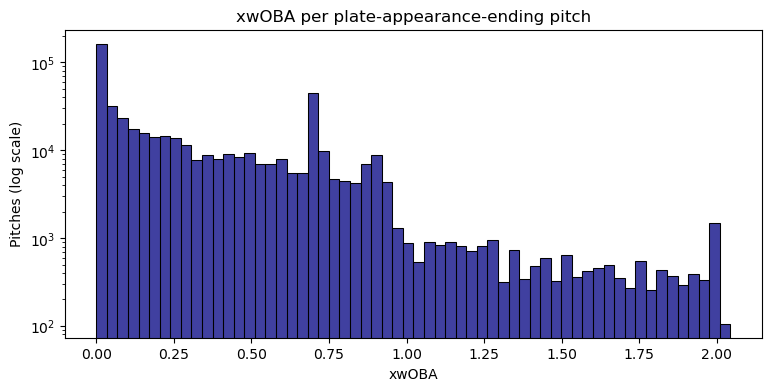

In [14]:
#xwOBA Result Distribution

plt.figure(figsize=(9, 4))
sns.histplot(df, x='xwoba_value', bins=60, color='Navy')
plt.yscale('log') 
plt.title('xwOBA per plate-appearance-ending pitch')
plt.xlabel('xwOBA'); plt.ylabel('Pitches (log scale)')
plt.show()

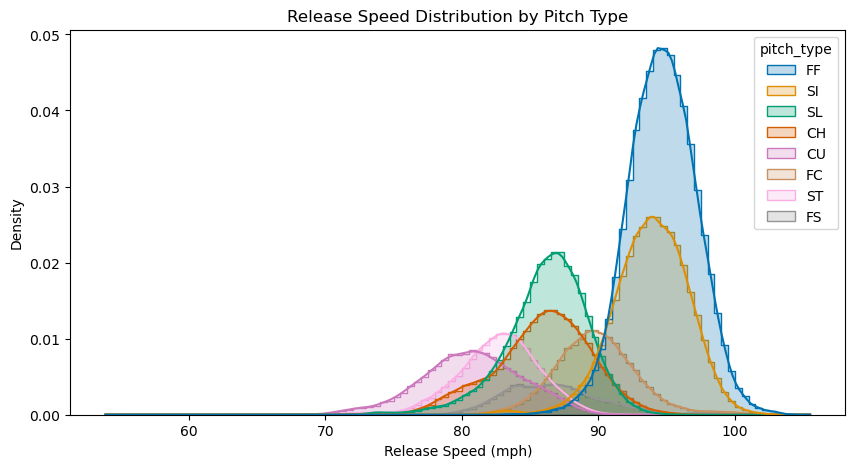

In [15]:
# Pitch Type Speed and Density

pitch_order = df['pitch_type'].value_counts().index

plt.figure(figsize=(10,5))
sns.histplot(data=df, x='release_speed', hue='pitch_type', hue_order=pitch_order,
             palette='colorblind', element='step', fill=True, kde=True,
             bins=np.arange(65, 105.5, 0.5), stat='density')
plt.title('Release Speed Distribution by Pitch Type')
plt.xlabel('Release Speed (mph)')
plt.ylabel('Density')
plt.show()

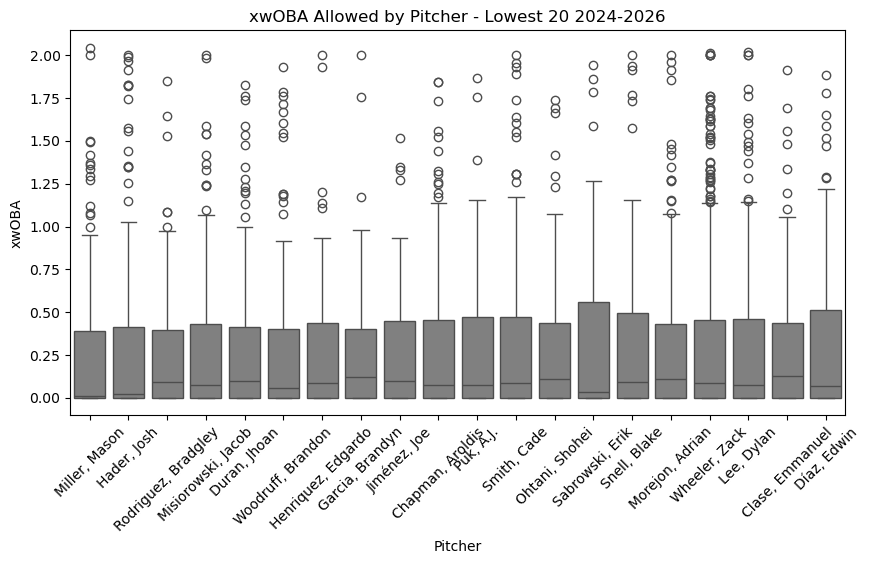

In [16]:
# xwOBA distribution by the top 20 players in the dataset
pitcher_order = df.groupby('player_name')['xwoba_value'].mean().sort_values().head(20).index

plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='player_name', y='xwoba_value', order=pitcher_order, color='grey')
plt.title('xwOBA Allowed by Pitcher - Lowest 20 2024-2026')
plt.xlabel('Pitcher')
plt.ylabel('xwOBA')
plt.xticks(rotation=45)
plt.show()

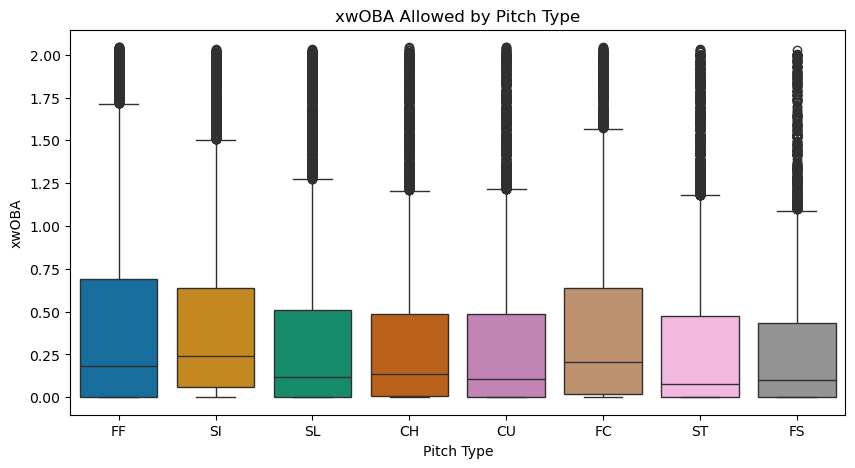

In [17]:
# xwOBA by pitch type

pitch_order = df['pitch_type'].value_counts().index

plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='pitch_type', y='xwoba_value', order=pitch_order, palette='colorblind')
plt.title('xwOBA Allowed by Pitch Type')
plt.xlabel('Pitch Type')
plt.ylabel('xwOBA')
plt.show()

The first two graphs look good and are expected, there is massive variation in data for pitch speeds even by type but obviously fastball is the most common. Also for xwOBA result distributions, obviously there is a ton at 0.0 for strikeouts and just really poor quality of contact results. It gets exponentially less frequent for higher xwOBA results, makes sense, home runs and perfect hits are rare. 

The third graph is interesting but not wrong. We see some of the names we expect to see at the top, Mason Miller, Ohtani, Chapman, etc. but also some weird ones. When looking at the weird ones though it is obvious that they are small sample size guys but at this point it's not worth filtering for that, we still get the main point here. 

For the last visual, it is defintiley worth remembering that fastballs, cutter, and sinkers seem to surrender the highest quality contact where as sliders and curveballs do seem to give up less good contact. It's not by much and not meant to generalizing for the rest of the project here but will be helpful to remember when we see some of our model results later on.  

## Modeling Set Up

In [18]:
# Because the end goal of our analysis is to apply our models to the 2026 White Sox Staff, 
# we will pull them out of the data now

wsox_filter = (qpitch_xwoba['pitching_team'] == 'CWS') & (qpitch_xwoba['season'] == 2026)
wsox = qpitch_xwoba[wsox_filter].copy()   # save for final section

mlb_pitch   = qpitch_xwoba[~wsox_filter] # everyone but the 2026 wsox
print(f'Training Data Rows (Rest of League 2024-2026) \n {len(mlb_pitch)}')

print(f'White Sox Data Rows 2026 \n {len(wsox)}')

Training Data Rows (Rest of League 2024-2026) 
 491178
White Sox Data Rows 2026 
 5311


In [19]:
# Need Pitch Types as Dummies , model can't read strings
mlb_pitch = pd.get_dummies(mlb_pitch, columns=['pitch_type'], prefix='pt')
wsox_pitch = pd.get_dummies(wsox, columns=['pitch_type'], prefix='pt')

### Group Shuffle Split

We split by pitcher using GroupShuffleSplit rather than splitting rows at random, because a single pitcher will throw thousands of near-identical pitches since they are unique to him. A random split would scatter them across train and test then the model would pick up on the bias and memorize individual pitchers instead of learning what makes a pitch effective.

 Grouping by pitcher guarantees that every pitch in the test set comes from an arm the model has never seen since we are grouping by category (pitcher) instead of using every row independently. This matches how the model will actually be used eventually, applied to White Sox pitchers held out of training entirely.

 For XG Boost we need 3 sets
  - Training Set - to fit models (70%)
  - Validation Set - to compare error on trained models (15%)
  - Test Set - Final Model scored on this (15%)

In [20]:
from sklearn.model_selection import GroupShuffleSplit

# Split Train and Test
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_idx, test_idx = next(gss.split(mlb_pitch, groups=mlb_pitch['pitcher']))

train_val = mlb_pitch.iloc[train_val_idx]
test = mlb_pitch.iloc[test_idx]

# split validation set (18% of train 85% is 15% of whole)
# val set is needed for XGBoost to compare models of training set
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.18, random_state=42)
train_idx, val_idx = next(gss2.split(train_val, groups=train_val['pitcher']))

train = train_val.iloc[train_idx]
val = train_val.iloc[val_idx]

print('train:', len(train), 'pitches,', train['pitcher'].nunique(), 'pitchers')
print('val:  ', len(val), 'pitches,', val['pitcher'].nunique(), 'pitchers')
print('test: ', len(test), 'pitches,', test['pitcher'].nunique(), 'pitchers')


train: 333562 pitches, 477 pitchers
val:   76759 pitches, 105 pitchers
test:  80857 pitches, 103 pitchers


In [21]:
#XG Boost Set Up , Feature Selection
features = [
    'pt_FF','pt_SI','pt_FC','pt_SL','pt_ST','pt_CU','pt_CH','pt_FS',
    'release_speed', 'release_spin_rate', 'release_extension',
    'release_pos_x_arm', 'release_pos_z',
    'pfx_x_in', 'pfx_z_in',
    'plate_x_in', 'plate_z',
    'same_hand', 'in_zone'
]

X_train = train[features]
y_train = train['xwoba_value']

X_val = val[features]
y_val = val['xwoba_value']

X_test = test[features]
y_test = test['xwoba_value']

print(X_train.shape, X_val.shape, X_test.shape)

(333562, 19) (76759, 19) (80857, 19)


In [22]:
import xgboost as xgb
import shap
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

baseline_pred = np.full(len(y_val), y_train.mean())
baseline_rmse = np.sqrt(mean_squared_error(y_val, baseline_pred))

#baseline RMSE to compare models against (essentially number to beat, std dev of guessing average)
print('baseline RMSE:', round(baseline_rmse, 4))


baseline RMSE: 0.3672


### First XGBoost Model

In [23]:
model = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=20,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric='rmse'
)

model.fit(X_train, y_train, 
          eval_set=[(X_val, y_val)], 
          verbose=100 # prints process logs every 100 before early stopping
)

print('best round:', model.best_iteration)

[0]	validation_0-rmse:0.36624
[100]	validation_0-rmse:0.35218
[200]	validation_0-rmse:0.35118
[300]	validation_0-rmse:0.35099
[400]	validation_0-rmse:0.35096
[403]	validation_0-rmse:0.35096
best round: 353


In [24]:
val_pred = model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, val_pred))
r2 = r2_score(y_val, val_pred)

print('baseline RMSE:', 0.3672)
print('xgboost  RMSE:', round(rmse, 4))
print('R2:', round(r2, 4))

baseline RMSE: 0.3672
xgboost  RMSE: 0.3509
R2: 0.0866


Better than baseline, but we will assess in different measures below. 

In [25]:
val_check = val[['pitcher', 'xwoba_value']].copy()
val_check['pred'] = val_pred

val_check['bin'] = pd.qcut(val_check['pred'], 10, labels=False)
calib = val_check.groupby('bin')[['pred', 'xwoba_value']].mean()
print(calib.round(3))

      pred  xwoba_value
bin                    
0    0.146        0.149
1    0.209         0.21
2    0.246        0.242
3    0.273         0.27
4    0.297          0.3
5    0.321        0.324
6    0.346        0.358
7    0.373        0.374
8    0.404        0.416
9    0.516        0.527


This table is a more important result than our R^2 of 0.087 above. The R^2 is rather poor but we don't want to know if the model can perfectly predict whether X pitch was a single, HR, or out. That would be impossible, we aren't trying to model batter choices or performance which would be an entirely different problem. If you are familiar with baseball, good pitches can be hit really well and you can get away with bad pitches as well, that noise in our data is inevitable. 

What we want to know is that if the model says a pitch is good, is it good on average? This binning approach and comparing the predicted vs actual values in our validation set does that. For each 10% bin of our validation set, the model is very close to being to right on average whether it was a bottom 10%, top 10%, or somewhere in between quality of pitch. 

In [26]:
by_pitcher = val_check.groupby('pitcher').agg(
    n=('xwoba_value', 'size'),
    actual=('xwoba_value', 'mean'),
    pred=('pred', 'mean')
)

print('correlation:', round(by_pitcher['actual'].corr(by_pitcher['pred']), 3))

by_pitcher.sample(10)

correlation: 0.562


,n,actual,pred
pitcher,,,
680573,1335,0.322872,0.322387
804636,219,0.30092,0.312493
669062,608,0.28501,0.310178
665871,1158,0.336812,0.339495
543243,2091,0.302949,0.303412
605452,595,0.342904,0.318943
670329,400,0.269136,0.311615
605135,1920,0.326963,0.342913
655889,305,0.289537,0.305260


This check is valueable as well. In our validation set, we want to see if our model is good at prediciting within a pitcher level data. We didn't let our model see pitcher IDs or names in the fitting process so this is a real test. 

Of the 105 pitchers in our validation set, we will see how the model predicted their pitches without knowing it was them, then look at the average xwOBA they surrended vs the average xwOBA we predict. Those two numbers had a 0.57 correlation, I'd say that is pretty good. 

This means the variance (0.57^2) is 0.32. 32% of pitcher level xwOBA is explained by ONLY the physical quality of their pitchers. The other 68% is by count, park, batter, sequencing, catcher, and more. To me that is significant. 

### Model Score on Test

In [27]:
test_pred = model.predict(X_test)

print('test RMSE:', round(np.sqrt(mean_squared_error(y_test, test_pred)), 4))
print('test R2:  ', round(r2_score(y_test, test_pred), 4))

# pitcher-level, same as above
test_check = test[['pitcher', 'xwoba_value']].copy()
test_check['pred'] = test_pred

by_pitcher_test = test_check.groupby('pitcher').agg(
    n=('xwoba_value', 'size'),
    actual=('xwoba_value', 'mean'),
    pred=('pred', 'mean')
)

print('correlation:', round(by_pitcher_test['actual'].corr(by_pitcher_test['pred']), 3))

test RMSE: 0.3509
test R2:   0.0843
correlation: 0.46


These results are consistent with our validation set. RMSE and R2 are nearly identical. The drop in correlation is small enough that I'm okay saying that it is within sample noise, it is close enough. 

## SHAP Analysis

base value: 0.3123


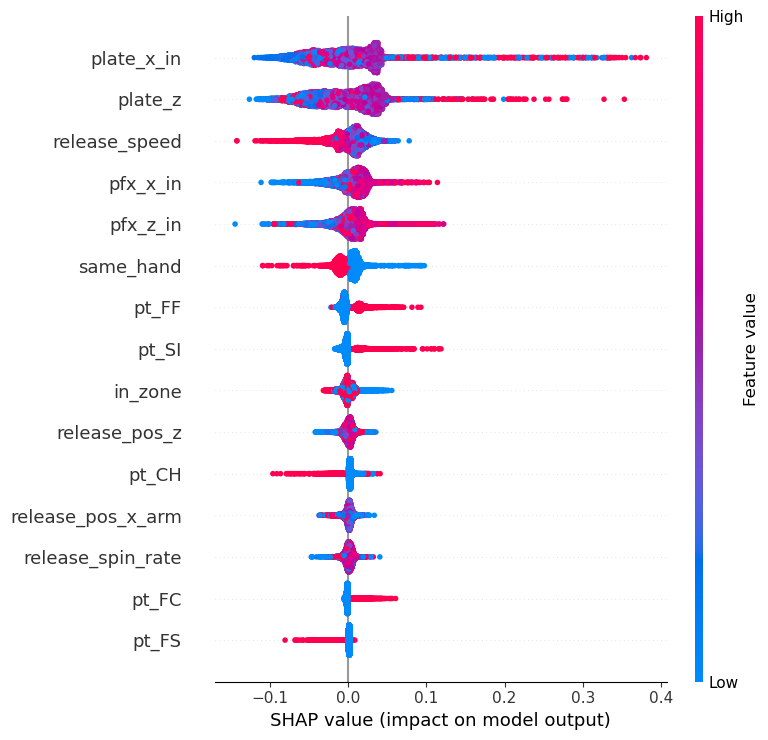

In [28]:
X_sample = X_test.sample(10000, random_state=42).astype(float)

contribs = model.get_booster().predict(xgb.DMatrix(X_sample), pred_contribs=True) 

# AI debug method - 
# version issue with the more average SHAP implementation , this fixed it with alternative method


shap_values = contribs[:, :-1]   
base_value = contribs[0, -1]    

print('base value:', round(float(base_value), 4))

shap.summary_plot(shap_values, X_sample, max_display=15)




In [29]:
importance = pd.DataFrame({
    'feature': X_sample.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print(importance.round(4).to_string(index=False))

          feature  mean_abs_shap
       plate_x_in         0.0364
          plate_z         0.0334
    release_speed         0.0160
         pfx_x_in         0.0156
         pfx_z_in         0.0145
        same_hand         0.0098
            pt_FF         0.0093
            pt_SI         0.0061
          in_zone         0.0054
    release_pos_z         0.0046
            pt_CH         0.0041
release_pos_x_arm         0.0039
release_spin_rate         0.0037
            pt_FC         0.0028
            pt_FS         0.0024
release_extension         0.0024
            pt_ST         0.0008
            pt_SL         0.0006
            pt_CU         0.0002


### SHAP Results

SHAP decomposes every individual prediction into additive contributions, the average then plus one number per feature based on it's value. The table below reports the average absolute SHAP value for the top 5 features in importance. This measures how much a feature matters, not whether it helps or hurts.

**Big Finding -> Location is roughly twice as important as stuff.** 
The two location features sum to 0.070, against 0.047 for velocity and both movement components combined. Every pitch-type dummy and all four release metrics together contribute less than `plate_z` alone.

**`plate_x_in` (0.0363)** — horizontal location (positive is arm-side for both handed pitchers) Both middle of the plate and far wide pitchers are penalized whereas just off the plate is ideal, this makes sense. Because the model is trained only on PA ending pitches, a pitch far off the plate is usually ball four, worth 0.691 wOBA.

**`plate_z` (0.0332)** — pitch height, and the most straightforward of the top features. Lower is better.

**`release_speed` (0.0166)** — velocity, the top feature that is purely "stuff." Harder pitches lower predicted xwOBA, but the effect is less than half the size of either location feature. On our SHAP graph, we see a really nice split here, less purple than either of the location features. 

**`pfx_x_in` and `pfx_z_in` (0.0154, 0.0147)** — arm-side run and induced vertical break. Both push predicted xwOBA up at high values, which could sound backwards until you notice that high IVB and arm-side run are what define a four-seamer or sinker. Those are the two pitch types that typically are hit the hardest and nearly every pitcher throws them. The movement features also largely encode the pitch type rather which also explains why the pitch-type dummies rank so low in predicative power, once the model knows velocity and movement, the label adds no more value. 

The features that are perfectly split by red and blue are binary, that is why there is no significant overlap, it does not mean distinction.


## A second model: stuff only

The SHAP results show that location (`plate_x_in`, `plate_z`) accounts for roughly twice as much predictive weight as velocity and movement combined. That is a real finding, but it rolls two different things into one. A large share of the location effect comes from ball 4 walks or HBP, worth 0.691 xwOBA. So the full model is measuring a lot of command rather than the quality of the pitch itself.

To combat this, I'm going to fit a second model (same model type) on the data with the three location features removed, leaving only characteristics intrinsic to the pitch: velocity, spin, movement, release point, pitch type, and handedness matchup.

- **Full model** = stuff + command
- **Stuff model** = arsenal quality, independent of where the pitch was thrown
- **The difference between them** = how much command contributes

This separation is what makes the analysis on White Sox pitchers actually result in actions. Two pitchers can allow identical contact quality for completely different reasons. They can have elite stuff thrown inaccurately or average stuff located precisely. Those problems call for very different interventions. Ranking the staff under both models identifies which pitchers depend on command and which are carried by raw stuff.

In [30]:
stuff_features = [f for f in features if f not in ['plate_x_in', 'plate_z', 'in_zone']]

stuff_model = xgb.XGBRegressor(         # exact same model as above
    n_estimators=2000, learning_rate=0.05, max_depth=6,             
    subsample=0.8, colsample_bytree=0.8, min_child_weight=20,       
    random_state=42, early_stopping_rounds=50, eval_metric='rmse'   
)


stuff_model.fit(train[stuff_features], y_train,
                eval_set=[(val[stuff_features], y_val)], verbose=False)

stuff_pred = stuff_model.predict(test[stuff_features])
print('stuff-only RMSE:', round(np.sqrt(mean_squared_error(y_test, stuff_pred)), 4))
print('stuff-only R2:  ', round(r2_score(y_test, stuff_pred), 4))

stuff-only RMSE: 0.3638
stuff-only R2:   0.0159


This R2 is a huge drop from our Full Model's R2 of 0.0848 but as we did above, let's look at it on a pitcher level and binned by results because that's our intended use case. 

In [41]:
stuff_check = test[['pitcher', 'xwoba_value']].copy()
stuff_check['pred'] = stuff_pred

stuff_check['bin'] = pd.qcut(stuff_check['pred'], 10, labels = False) # split xwOBA values into ten bins ranked
calib = stuff_check.groupby('bin')[['pred', 'xwoba_value']].mean()
print(calib.round(3))

      pred  xwoba_value
bin                    
0    0.235        0.229
1    0.267        0.266
2    0.283        0.276
3    0.295        0.285
4    0.307          0.3
5    0.321        0.326
6    0.335        0.329
7    0.348         0.35
8    0.361        0.361
9    0.385        0.387


Looks good here, not as good as the full-model but it still is pretty close here and shows that it clealry has some predicative power in generally good pitches vs bad. 

In [32]:
# Let's look at how good at is on a pitcher level on our test data
bp = stuff_check.groupby('pitcher').agg(
    n=('xwoba_value', 'size'),
    actual=('xwoba_value', 'mean'),
    pred=('pred', 'mean')
)

print('stuff-only pitcher correlation:', round(bp['actual'].corr(bp['pred']), 3))

# quick look at data
bp.sample(10)

stuff-only pitcher correlation: 0.376


,n,actual,pred
pitcher,,,
640462,312,0.252724,0.309134
669854,1012,0.308832,0.314524
592791,1555,0.323572,0.318584
642152,240,0.343848,0.319382
623167,880,0.340605,0.333700
693312,440,0.331089,0.291352
682990,865,0.305334,0.327126
543859,423,0.334986,0.321160
687377,320,0.32479,0.306127


### Stuff vs. command: pitch level vs. pitcher level

| Model | Pitch-level R² | Pitcher-level r | Pitcher-level r² |
|---|---|---|---|
| Full (stuff + location) | 0.0848 | 0.463 | 0.214 |
| Stuff only | 0.0157 | 0.383 | 0.147 |
| **Stuff as share of full** | **18%** | | **69%** |

Removing the three location features costs the model ~82% of its pitch-level explanatory power, but only 31% of its pitcher-level explanatory power. Stuff accounts for 18% of what can be explained about a single plate appearance, and 69% of what can be explained about a pitcher's season. This is a big finding and confirms that running a second model here was the right call. 

This makes sense, on an AB result level, a pitch is subject to noise from situation or batter approach and behavior, much of which is outside of the pitcher's control especially if they are a reliever. Also, any pitchers could just be having a bad day on locating pitches. However, stuff travels, not everyone can make a slider move or throw a fastball as fast like the best can. 

The results here justify looking at pitchers pitch characteristics independent of location despite the extremely low R2. This stuff model is a much weaker predictor of what happens in any given at-bat but is meaningfully strong at longer-term player specific evaluation. 


### Stuff-Only SHAP

base value: 0.3123


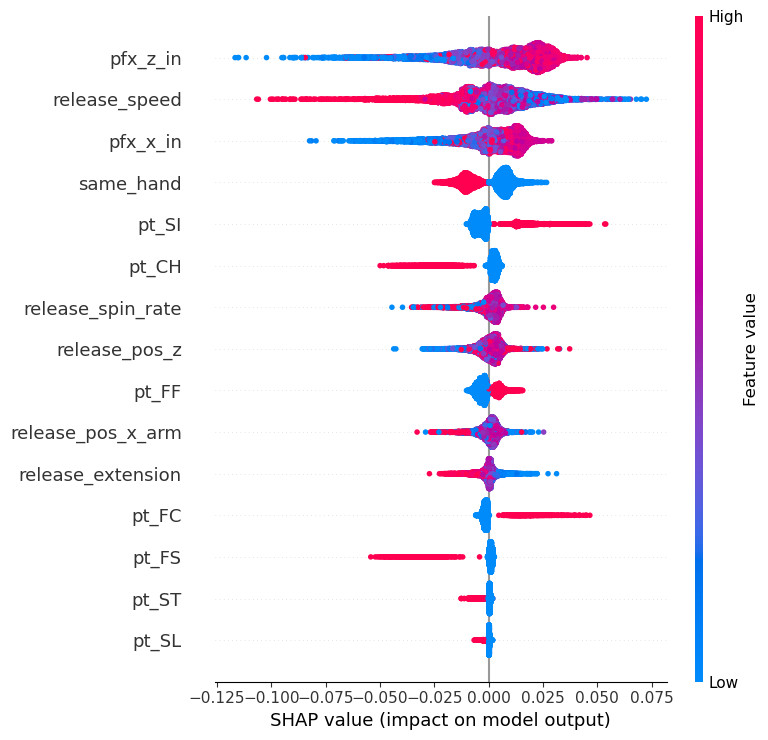

In [ ]:
X_sample = X_test[stuff_features].sample(10000, random_state=42).astype(float)

contribs = stuff_model.get_booster().predict(xgb.DMatrix(X_sample), pred_contribs=True)

shap_values = contribs[:, :-1]   
base_value = contribs[0, -1]    

print('base value:', round(float(base_value), 4))

shap.summary_plot(shap_values, X_sample, max_display=15)

In [34]:
importance = pd.DataFrame({
    'feature': X_sample[stuff_features].columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print(importance.round(4).to_string(index=False))

          feature  mean_abs_shap
         pfx_z_in         0.0180
    release_speed         0.0144
         pfx_x_in         0.0113
        same_hand         0.0089
            pt_SI         0.0064
            pt_CH         0.0053
release_spin_rate         0.0040
    release_pos_z         0.0040
            pt_FF         0.0038
release_pos_x_arm         0.0034
release_extension         0.0029
            pt_FC         0.0028
            pt_FS         0.0026
            pt_ST         0.0007
            pt_SL         0.0006
            pt_CU         0.0001


### Stuff-Only SHAP Results

This is really interesting because even non-location factors here actually change order in this stuff-only model. `pfx_z_in` jumps `release_speed` as the most important predictor. Below is a summary of the findings.

**Movement outranks velocity.** In the full model, velocity was the strongest stuff feature, once location is removed, induced vertical break takes over. Low vertical break pushes predicted xwOBA down, high break pushes it up this is largely breaking-balls. Their effect outruns the smaller effect of a FF having positive IVB being generally looked at as a positive.

**Velocity is the cleanest relationship on the plot.** `release_speed` shows almost no mixing, hard pitches sit left (better), soft pitches right (worse).

**Pitch type matters selectively.** `pt_SI`, `pt_CH`, and `pt_FS` carry real weight, while `pt_SL`, `pt_ST`, and `pt_CU` contribute essentially nothing. Sliders and curveballs appear to be fully described by their measured velocity and movement, so the label adds no information. Sinkers, change-up, and splitters add predicative power just based on their category, probably because they are often used when not expected. 

**Release metrics become visible.** `release_extension` and `release_pos_z` were negligible in the full model but are notable here, with greater extension lowering predicted xwOBA, this is consistent with the idea that releasing closer to the plate reduces the hitter's reaction time.

Note: Magnitudes should not be compared between the two models for the same reason we don't compare the R2s, we have proof on the pitcher-level that our stuff-only model is meaningful. 

# White Sox Analysis using Both Models

Now using a combination of both models, we will evaluate the 2026 Chicago White Sox pitching staff using their statcast data from the full 2026 regular season which concluded on 9/27/26

In [35]:
# need to add dummies for pitch types for wsox
# we didn't do that till after we split the data off

dummies = pd.get_dummies(wsox['pitch_type'], prefix='pt')
wsox = pd.concat([wsox, dummies], axis=1)

In [ ]:
X_wsox_full  = wsox[features].astype(float)
X_wsox_stuff = wsox[stuff_features].astype(float)

wsox['pred_full']  = model.predict(X_wsox_full)
wsox['pred_stuff'] = stuff_model.predict(X_wsox_stuff)

sox = wsox.groupby('player_name').agg(
    n=('xwoba_value', 'size'),
    p_stuff=('pred_stuff', 'mean'),
    p_full=('pred_full', 'mean'),
    expected=('xwoba_value', 'mean'),
    actual=('woba_value', 'mean')
)
sox['command'] = sox['p_stuff'] - sox['p_full']   # Positive = location improves on stuff
sox['luck']    = sox['actual'] - sox['expected']  # Positive = gotten unlucky

sox = sox[sox['n'] >= 50].sort_values('actual')
print(sox.round(3))

                         n  p_stuff  p_full  expected  actual  command   luck
player_name                                                                  
Taylor, Grant          335    0.267   0.274     0.267   0.263   -0.007 -0.004
Newcomb, Sean          366    0.325   0.339     0.318   0.291   -0.014 -0.027
Richards, Trevor       320    0.347   0.337     0.312   0.299    0.010 -0.013
Burke, Sean            712    0.311   0.308       0.3   0.306    0.003  0.006
Hicks, Jordan          207    0.286   0.278     0.259   0.313    0.008  0.053
Domínguez, Seranthony  160    0.297   0.307     0.328   0.314   -0.010 -0.014
Hudson, Bryan          273    0.327   0.334     0.278   0.316   -0.007  0.038
Martin, Davis          592    0.325   0.340     0.329   0.325   -0.016 -0.004
Fedde, Erick           601    0.312   0.307     0.334    0.33    0.006 -0.004
Leasure, Jordan         75    0.297   0.279     0.417   0.343    0.018 -0.074
Schultz, Noah          319    0.330   0.342     0.358   0.344   

Results here look consistent and correct for the most part. Jordan Leasure and Huascar Brazoban are both under 100 for result pitches so their information should be taken with a grain of salt but will include in this table still. 

In [37]:
# Who are the biggest movers between the Stuff and Full Models? 

print('Sox Pitchers who throw strikes but dont have good stuff:\n')
print(sox.sort_values('command', ascending=False).round(3).head(3), "\n")

print('Sox Pitchers who have good stuff but dont throw strikes:\n')
print(sox.sort_values('command', ascending=True).round(3).head(3))

Sox Pitchers who throw strikes but dont have good stuff:

                    n  p_stuff  p_full  expected  actual  command   luck
player_name                                                             
Leasure, Jordan    75    0.297   0.279     0.417   0.343    0.018 -0.074
Richards, Trevor  320    0.347   0.337     0.312   0.299    0.010 -0.013
Castillo, Luis    147    0.320   0.311     0.355   0.422    0.010  0.067 

Sox Pitchers who have good stuff but dont throw strikes:

                     n  p_stuff  p_full  expected  actual  command   luck
player_name                                                              
Brazobán, Huascar   59    0.314   0.359     0.398   0.385   -0.044 -0.013
Murphy, Chris      150    0.301   0.342     0.303   0.346   -0.041  0.044
Martin, Davis      592    0.325   0.340     0.329   0.325   -0.016 -0.004


In [52]:
# How do pitchers arsenal grade out on the stuff model
# Can look for low stuff model and low relative usage rate to suggest pitchers throw it more

arsenal = wsox.groupby(['player_name','pitch_type']).agg(
    n=('pred_stuff','size'),
    pred_xwoba=('pred_stuff','mean'),
)
arsenal['usage'] = arsenal['n'] / arsenal.groupby('player_name')['n'].transform('sum')

#Quick look at a few pitchers
print(f'--------Sean Burke arsenal grades on Stuff Model--------')
print(arsenal.loc['Burke, Sean'],'\n')

print(f'--------Luis Castillo arsenal grades on Stuff Model--------')
print(arsenal.loc['Castillo, Luis'])

print('\n Both pitchers have high slider and cutter grades but under-use them \n' \
' This could very well be due to injury concerns as both are riskier. \n\n' \
' Castillo throws a great change-up even in a small sample size but throws \n' \
' his FF and SI which grade lower more often, there is potential for action there')

--------Sean Burke arsenal grades on Stuff Model--------
              n  pred_xwoba     usage
pitch_type                           
CH            8    0.293426  0.011236
CU          125    0.291122  0.175562
FC           61    0.328022  0.085674
FF          285    0.314998  0.400281
SI          105    0.349710  0.147472
SL          128    0.282294  0.179775 

--------Luis Castillo arsenal grades on Stuff Model--------
             n  pred_xwoba     usage
pitch_type                          
CH          34    0.293743  0.231293
FF          54    0.331646  0.367347
SI          43    0.335052  0.292517
SL          16    0.299673  0.108844

 Both pitchers have high slider and cutter grades but under-use them 
 This could very well be due to injury concerns as both are riskier. 

 Castillo throws a great change-up even in a small sample size but throws 
 his FF and SI which grade lower more often, there is potential for action there


In [ ]:
# Assining Normalized Scores to White Sox Pithers
# Similar to FanGraphs Stuff+ but modeled on xwOBA (quality of contact) rather than expected Run Value

lg_stuff = stuff_model.predict(mlb_pitch[stuff_features].astype(float)).mean()
lg_full  = model.predict(mlb_pitch[features].astype(float)).mean()

print('league avg stuff:', round(lg_stuff, 4), '| league avg full:', round(lg_full, 4), '\n')

sox['stuff_plus'] = (100 * (1 + (lg_stuff - sox['p_stuff']) / lg_stuff)).astype(int)
sox['full_plus']  = (100 * (1 + (lg_full  - sox['p_full'])  / lg_full)).astype(int)       # fliipped because lower

print(sox[['n','p_stuff','stuff_plus','p_full','full_plus']]
      .sort_values('stuff_plus', ascending=False).round(3))


league avg stuff: 0.3126 | league avg full: 0.3127 

                         n  p_stuff  stuff_plus  p_full  full_plus
player_name                                                       
Taylor, Grant          335    0.267         114   0.274        112
Hicks, Jordan          207    0.286         108   0.278        111
Domínguez, Seranthony  160    0.297         105   0.307        101
Leasure, Jordan         75    0.297         105   0.279        110
Murphy, Chris          150    0.301         103   0.342         90
Burke, Sean            712    0.311         100   0.308        101
Fedde, Erick           601    0.312         100   0.307        101
Eisert, Brandon        115    0.314          99   0.307        101
Brazobán, Huascar       59    0.314          99   0.359         85
Castillo, Luis         147    0.320          97   0.311        100
Newcomb, Sean          366    0.325          96   0.339         91
Martin, Davis          592    0.325          96   0.340         91
Kay, Anth

### 2026 White Sox staff grades + takeaways

Both models are scaled so 100 is league average and 110 is 10% better than average. The two league reference points are nearly identical (0.3126 stuff, 0.3127 full), so the grades are directly comparable.

**The staff is slightly below average overall** 

Pitch-weighted, roughly 99 on stuff and 98 on full. Location makes the group marginally worse rather than better.

**Grant Taylor is the clear standout.** 

He grades best on both models (114 stuff, 112 full) over 335 plate-appearance-ending pitches. Jordan Hicks (108/110) is the only other arm with a sufficiently large sample that grades well on both.

**Chris Murphy is the most actionable case.** 

His stuff grades above average (104) but his full grade collapses to 90, a 14-point loss almost entirely attributable to location. That is a command problem sitting on top of a usable arsenal, which is a more reasonable fix than a stuff deficiency. Huascar Brazobán shows the same pattern more severely (99 to 84), though on only on a small sample of 59 pitches.

**Grant Taylor should be moved to a starting role.** 

Grant Taylor has been the subject of debate among White Sox fans recently. Some attribute his success to being in the bullpen while others are calling for him to be given a starting role. This data suggests he is more than capable of assuming a spot in the starting rotation next season. His stuff as well as location are both elite, he should be efficient enough to pitch in bulk in the future barring some underlying fatigue concerns we don't know about. 

**Trevor Richards is a curious case.** 

His stuff grades below average (88) and his full grade a little better at 93. However, he ranks third in lowest wOBA allowed and seventh in lowest xwOBA allowed. He has clearly found some success this season despite his underlying metrics grading out well below average. Perhaps it could be selection bias for him coming out of the bullpen only in very favorable spots. If that isn't the case, the White Sox should be careful to send him out to the mound in important games given his underlying metrics suggesting he is due for a regression to the mean. 


In [ ]:
# Environment / package versions for reproducibility
# claude AI written code for version checks
import sys, platform
from importlib.metadata import version, PackageNotFoundError

print("Python     :", sys.version.split()[0])
print("Platform   :", platform.platform())
print("-" * 40)

packages = [
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "xgboost",
    "shap",
    "pybaseball",
]

for pkg in sorted(packages):
    try:
        print(f"{pkg:<15}: {version(pkg)}")
    except PackageNotFoundError:
        print(f"{pkg:<15}: not installed")


Python     : 3.10.19
Platform   : macOS-26.5.1-arm64-arm-64bit
----------------------------------------
matplotlib     : 3.8.4
numpy          : 1.26.4
pandas         : 2.2.2
pybaseball     : 2.2.7
scikit-learn   : 1.7.2
seaborn        : 0.13.2
shap           : 0.49.1
xgboost        : 3.2.0
